# 04 · COLMAP Multi-View Reconstruction  ← **Milestone Artifact #1**

**Goal:** sparse 3D cloud of one tree from a skyward orbit. Pipeline this notebook runs:

```
raw frames → CLAHE contrast → tree-color mask → COLMAP SfM → PLY + figure + poses
```

The CLAHE + tree-color-mask preprocessing forces SIFT to find features on the trunk/branches
rather than the leaves and background.


In [1]:
# Standard preamble — every notebook seeds np.random.seed(131).
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
np.random.seed(131)

import matplotlib.pyplot as plt
%matplotlib inline


## 0. Configuration

Set `TREE_ID` to whichever capture you want to reconstruct. Three derived
directories: raw frames (from notebook 01), CLAHE-enhanced, and tree-masked.


In [2]:
from src import sfm, viz
import cv2
import shutil

TREE_ID = "tree_5"   # change me per capture

RAW_FRAMES_DIR    = PROJECT_ROOT / "data" / "frames" / TREE_ID
CLAHE_FRAMES_DIR  = PROJECT_ROOT / "data" / "frames" / f"{TREE_ID}_clahe"
MASKED_FRAMES_DIR = PROJECT_ROOT / "data" / "frames" / f"{TREE_ID}_masked"
WORKSPACE         = PROJECT_ROOT / "outputs" / "reconstructions" / f"{TREE_ID}_masked_colmap"

if not RAW_FRAMES_DIR.exists():
    raise FileNotFoundError(
        f"Raw frames not found at {RAW_FRAMES_DIR}.\n"
        "Run notebook 01 first to extract frames for this tree."
    )

n_raw = len(list(RAW_FRAMES_DIR.glob("frame_*.png")))
print(f"Tree: {TREE_ID}   raw frames: {n_raw}")


Tree: tree_5   raw frames: 80


## 1. CLAHE contrast preprocessing

Apply CLAHE (Contrast Limited Adaptive Histogram Equalization) to the L channel
of each frame in LAB color space. This brings out bark detail in the dark trunk
without blowing out the bright sky — gives SIFT more texture to find on the trunk.

Skipped if the CLAHE frame directory is already populated.


In [3]:
CLAHE_FRAMES_DIR.mkdir(parents=True, exist_ok=True)
src_frames = sorted(RAW_FRAMES_DIR.glob("frame_*.png"))
if len(list(CLAHE_FRAMES_DIR.glob("frame_*.png"))) < len(src_frames):
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    for p in src_frames:
        img = cv2.imread(str(p))
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        lab[:, :, 0] = clahe.apply(lab[:, :, 0])
        enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
        cv2.imwrite(str(CLAHE_FRAMES_DIR / p.name), enhanced)
    print(f"Wrote {len(src_frames)} CLAHE-enhanced frames to {CLAHE_FRAMES_DIR}")
else:
    print(f"Reusing existing CLAHE frames in {CLAHE_FRAMES_DIR}")


Reusing existing CLAHE frames in /Users/colevanhersett/Developer/uni/CS_131/final_proj/data/frames/tree_5_clahe


## 2. Tree-color mask — preview on one frame

Sample bark hue from a known trunk location (bottom-center of the frame, where
the trunk reliably sits in a skyward capture). Build an HSV mask of pixels
within hue tolerance, clean it up morphologically, feather the boundary so SIFT
doesn't fire on the artificial mask edge.

Tune `sample_y_frac` and `hue_tol` based on the preview output, then move on.


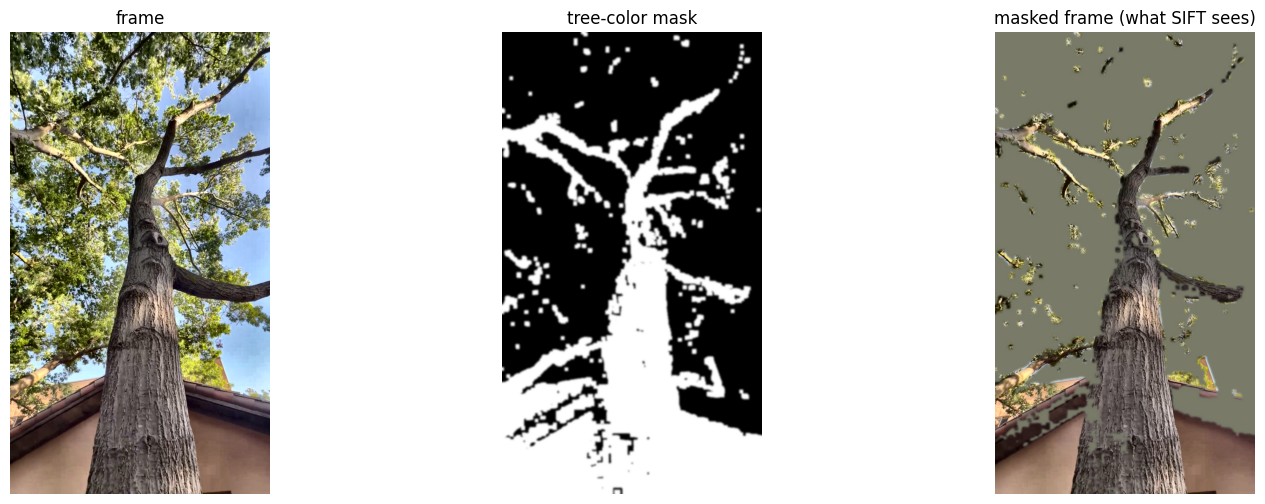

In [4]:
def tree_color_mask(img_bgr,
                    sample_x_frac=0.5, sample_y_frac=0.72,   # where to sample bark color
                    sample_half=25,                           # 50x50 sample patch
                    hue_tol=20,                               # hue tolerance ± (0-179)
                    feather_px=21):                           # boundary feathering
    h, w = img_bgr.shape[:2]
    cx, cy = int(w * sample_x_frac), int(h * sample_y_frac)
    s = sample_half
    patch_hsv = cv2.cvtColor(img_bgr[cy-s:cy+s, cx-s:cx+s], cv2.COLOR_BGR2HSV)
    h_med = int(np.median(patch_hsv[:, :, 0]))
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    # Permissive on saturation/value so shadows + highlights both pass.
    lo = np.array([max(0,   h_med - hue_tol), 0,  0])
    hi = np.array([min(179, h_med + hue_tol), 255, 255])
    mask = cv2.inRange(img_hsv, lo, hi)
    k = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  k)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k)
    mask = cv2.dilate(mask, cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9)))
    return cv2.GaussianBlur(mask.astype(np.float32) / 255.0,
                            (feather_px, feather_px), 0)


def apply_mask(img_bgr, mask_float):
    fill = np.full_like(img_bgr, np.mean(img_bgr, axis=(0, 1)).astype(np.uint8))
    m = mask_float[:, :, None]
    return (img_bgr * m + fill * (1 - m)).astype(np.uint8)


# Preview on a middle frame so you can sanity-check before running the batch.
clahe_frames = sorted(CLAHE_FRAMES_DIR.glob("frame_*.png"))
sample = cv2.imread(str(clahe_frames[len(clahe_frames) // 2]))
m_preview = tree_color_mask(sample)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(cv2.cvtColor(sample, cv2.COLOR_BGR2RGB));                       axes[0].set_title("frame")
axes[1].imshow(m_preview, cmap="gray", vmin=0, vmax=1);                        axes[1].set_title("tree-color mask")
axes[2].imshow(cv2.cvtColor(apply_mask(sample, m_preview), cv2.COLOR_BGR2RGB)); axes[2].set_title("masked frame (what SIFT sees)")
for a in axes: a.axis("off")
plt.show()


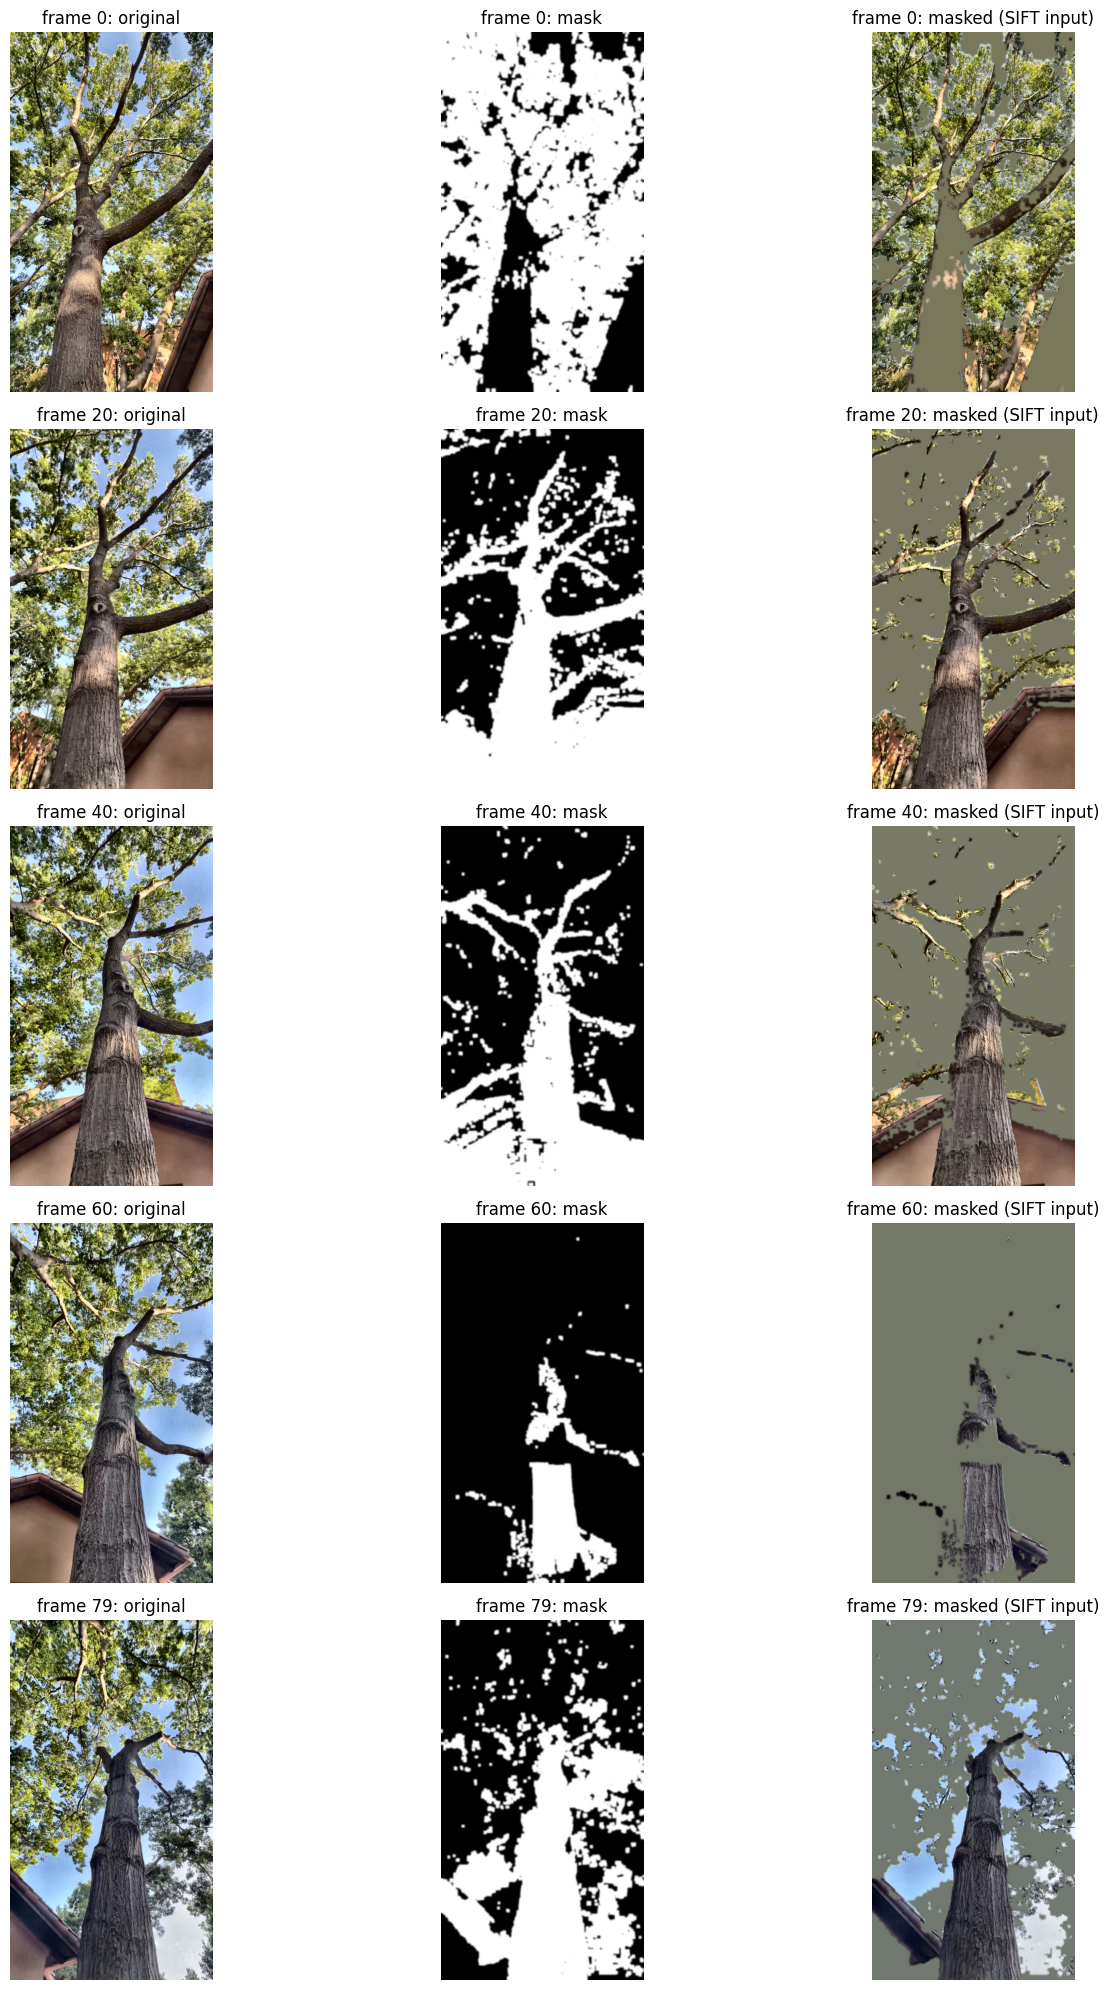

In [5]:
# Multi-frame preview — sanity-check the mask across the full orbit.
clahe_frames = sorted(CLAHE_FRAMES_DIR.glob("frame_*.png"))
n = len(clahe_frames)
preview_indices = [0, n // 4, n // 2, 3 * n // 4, n - 1]   # 5 frames evenly spaced

fig, axes = plt.subplots(len(preview_indices), 3,
                          figsize=(15, 4 * len(preview_indices)))
for row, idx in enumerate(preview_indices):
    img = cv2.imread(str(clahe_frames[idx]))
    m = tree_color_mask(img)
    axes[row, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[row, 0].set_title(f"frame {idx}: original")
    axes[row, 1].imshow(m, cmap="gray", vmin=0, vmax=1)
    axes[row, 1].set_title(f"frame {idx}: mask")
    axes[row, 2].imshow(cv2.cvtColor(apply_mask(img, m), cv2.COLOR_BGR2RGB))
    axes[row, 2].set_title(f"frame {idx}: masked (SIFT input)")
    for col in range(3):
        axes[row, col].axis("off")
plt.tight_layout()
plt.show()

## 3. Apply the mask to every frame

Writes a complete set of masked frames to `MASKED_FRAMES_DIR`. These are what
COLMAP will actually run on.


In [6]:
MASKED_FRAMES_DIR.mkdir(parents=True, exist_ok=True)
for p in sorted(CLAHE_FRAMES_DIR.glob("frame_*.png")):
    img = cv2.imread(str(p))
    cv2.imwrite(str(MASKED_FRAMES_DIR / p.name), apply_mask(img, tree_color_mask(img)))
print(f"Wrote {len(list(MASKED_FRAMES_DIR.glob('frame_*.png')))} masked frames to {MASKED_FRAMES_DIR}")


Wrote 80 masked frames to /Users/colevanhersett/Developer/uni/CS_131/final_proj/data/frames/tree_5_masked


## 4. Run COLMAP on the masked frames

Single COLMAP call. We delete any old workspace first so COLMAP doesn't try to
reuse a partial database from a previous run.


In [7]:
shutil.rmtree(WORKSPACE, ignore_errors=True)
sparse_dir = sfm.run_colmap(
    image_dir=MASKED_FRAMES_DIR, workspace_dir=WORKSPACE,
    quality="medium", single_camera=True, use_gpu=True,
)
print(f"COLMAP produced model at {sparse_dir}")


I20260525 20:59:39.926529 0x16f16f000 automatic_reconstruction.cc:251] === Feature extraction ===
I20260525 20:59:39.927075 0x16f1fb000 feature_extraction.cc:506] === Feature extraction ===
I20260525 20:59:39.951185 0x16fa2f000 sift.cc:757] Creating SIFT GPU feature extractor
I20260525 20:59:40.649983 0x16fabb000 feature_extraction.cc:284] Processed file [1/80]
I20260525 20:59:40.650002 0x16fabb000 feature_extraction.cc:287]   Name:            frame_00000.png
I20260525 20:59:40.650005 0x16fabb000 feature_extraction.cc:296]   Dimensions:      1080 x 1920
I20260525 20:59:40.650007 0x16fabb000 feature_extraction.cc:299]   Camera:          #1 - SIMPLE_RADIAL
I20260525 20:59:40.650011 0x16fabb000 feature_extraction.cc:302]   Focal Length:    2304.00px
I20260525 20:59:40.650014 0x16fabb000 feature_extraction.cc:306]   Features:        4304 (SIFT)
I20260525 20:59:40.689578 0x16fabb000 feature_extraction.cc:284] Processed file [2/80]
I20260525 20:59:40.689622 0x16fabb000 feature_extraction.cc:

COLMAP produced model at /Users/colevanhersett/Developer/uni/CS_131/final_proj/outputs/reconstructions/tree_5_masked_colmap/sparse/0


## 5. Load the sparse model + save the cloud as PLY

In [8]:
recon = sfm.load_sparse_model(sparse_dir)
print(f"Registered images: {len(recon.image_names)}")
print(f"3D points:         {len(recon.points_3d)}")

ply_path = PROJECT_ROOT / "outputs" / "reconstructions" / f"{TREE_ID}_sparse.ply"
sfm.save_ply(ply_path, recon.points_3d, recon.point_colors)
print(f"Saved → {ply_path}")


Registered images: 80
3D points:         18206
Saved → /Users/colevanhersett/Developer/uni/CS_131/final_proj/outputs/reconstructions/tree_5_sparse.ply


In [9]:
# Outlier filter — drop points far from the main trunk cluster.
center = np.median(recon.points_3d[:, :2], axis=0)
xy_dist = np.linalg.norm(recon.points_3d[:, :2] - center, axis=1)
mad = np.median(xy_dist)
keep = xy_dist < 4 * mad

xyz_clean = recon.points_3d[keep]
rgb_clean = recon.point_colors[keep] if recon.point_colors is not None else None
print(f"Kept {int(keep.sum())} / {len(recon.points_3d)} points after outlier filter")

# Save the cleaned cloud as a separate PLY (raw stays as <TREE_ID>_sparse.ply).
ply_clean = PROJECT_ROOT / "outputs" / "reconstructions" / f"{TREE_ID}_sparse_clean.ply"
sfm.save_ply(ply_clean, xyz_clean, rgb_clean)
print(f"Saved cleaned cloud → {ply_clean}")

Kept 15803 / 18206 points after outlier filter
Saved cleaned cloud → /Users/colevanhersett/Developer/uni/CS_131/final_proj/outputs/reconstructions/tree_5_sparse_clean.ply


## 6. Render the milestone figure + multi-angle inspection

The single-angle render is the milestone artifact. The 4 rotated views below
let you see whether the cloud is actually tree-shaped (look for a vertical core
with horizontal/diagonal branches fanning off).


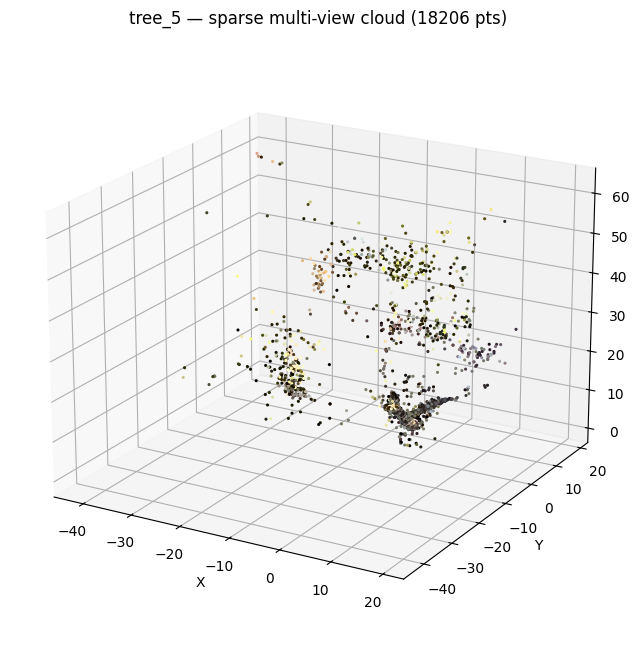

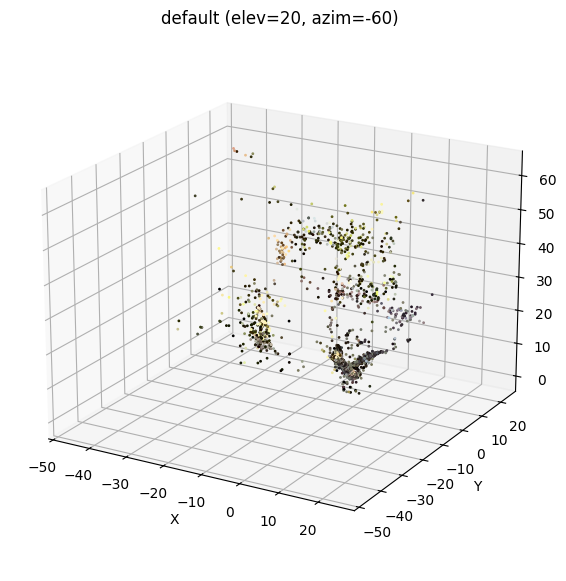

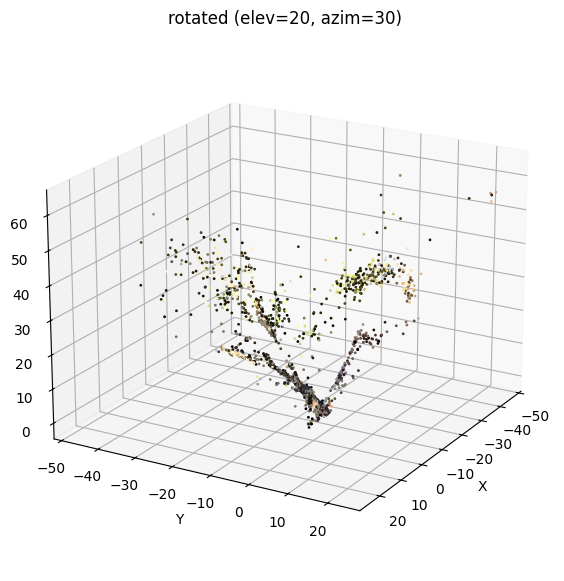

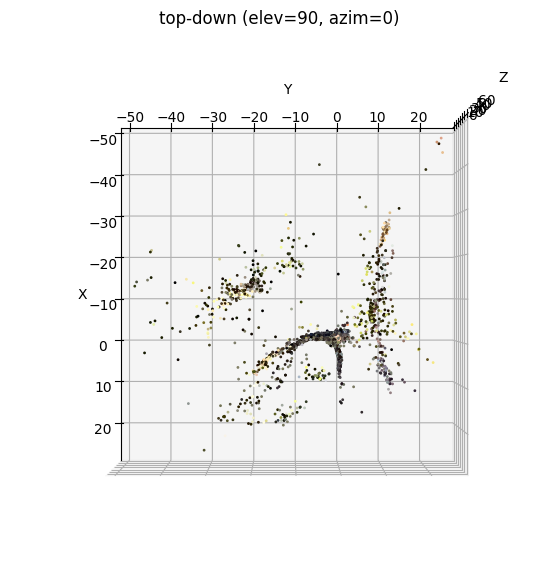

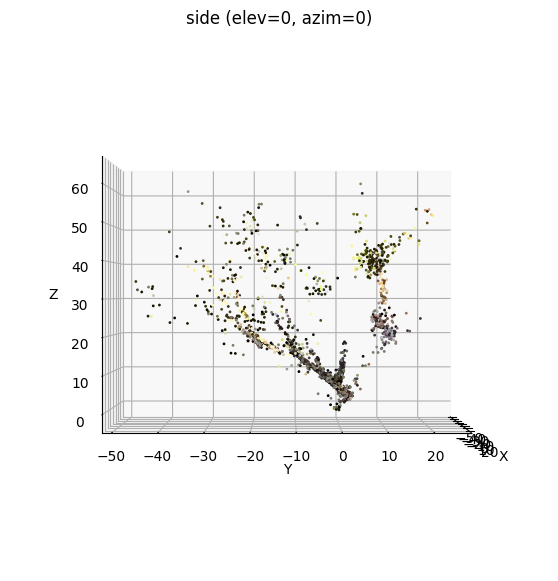

In [10]:
# Milestone figure — saved to outputs/figures/milestone_cloud_<TREE_ID>.png
fig = viz.plot_point_cloud(
    recon.points_3d, recon.point_colors,
    title=f"{TREE_ID} — sparse multi-view cloud ({len(recon.points_3d)} pts)",
)
viz.save_fig(fig, f"milestone_cloud_{TREE_ID}.png")
plt.show()

# Multi-angle inspection.
xyz = recon.points_3d
rgb = recon.point_colors.astype(float) / 255.0 if recon.point_colors is not None else None
for elev, azim, label in [(20, -60, "default"), (20, 30, "rotated"),
                           (90, 0, "top-down"), (0, 0, "side")]:
    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2],
               s=1, c=rgb if rgb is not None else "tab:blue", depthshade=False)
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(f"{label} (elev={elev}, azim={azim})")
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    plt.show()


## 7. Save per-image projection matrices

Notebook 06 (the reprojection filter) needs P = K [R | t] for every registered image.


In [11]:
Ps = sfm.projection_matrices(recon)
np.savez(
    PROJECT_ROOT / "outputs" / "reconstructions" / f"{TREE_ID}_poses.npz",
    projections=np.array(Ps),
    image_names=np.array(recon.image_names),
)
print(f"Saved {len(Ps)} projection matrices.")


Saved 80 projection matrices.


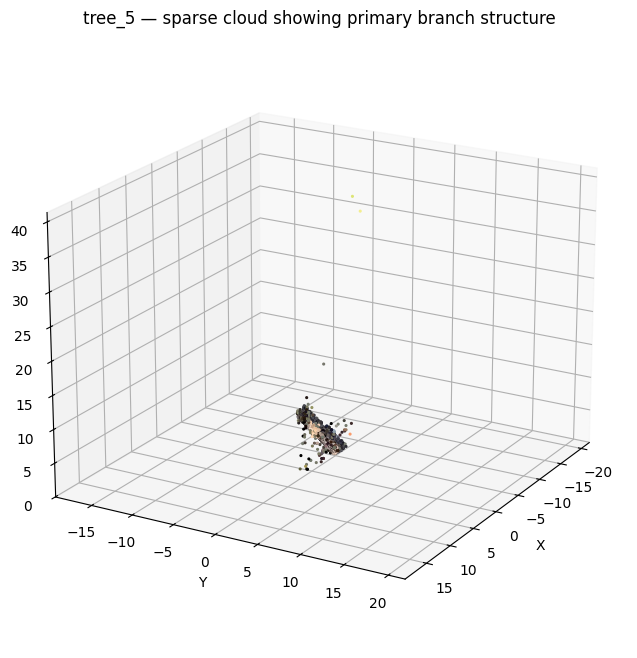

In [12]:
fig = viz.plot_point_cloud(
    xyz_clean, rgb_clean,
    title=f"{TREE_ID} — sparse cloud showing primary branch structure",
    elev=20, azim=30,   # the angle where the Y-fork reads clearly
)
viz.save_fig(fig, "milestone_cloud.png")
plt.show()